In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import zipfile
import pyarrow

In [2]:
path = '/home/m/monroy/rubin-user/spectra_cmfgen/'
main_file = 'CMFGEN.zip'
outdir = path

In [3]:
# Ruta al archivo .zip principal
main_zip = os.path.join(path,main_file)

# Directorio temporal para extraer los archivos .zip internos
temp_dir = os.path.join(path,'temp_zip')

# Crear el directorio temporal si no existe
os.makedirs(temp_dir, exist_ok=True)

# Extraer solo los archivos .zip del .zip principal
with zipfile.ZipFile(main_zip, 'r') as zip_ref:
    # Listar todos los archivos dentro del .zip principal
    all_files = zip_ref.namelist()

    # Filtrar solo los archivos .zip
    files_zip = [file_ for file_ in all_files if file_.endswith('.zip')]

    # Extraer solo los archivos .zip
    for file_ in files_zip:
        zip_ref.extract(file_, temp_dir)


In [4]:
with zipfile.ZipFile(os.path.join(temp_dir,files_zip[0]), 'r') as zip_ref:
    # Listar los archivos dentro del .zip
    files_ = zip_ref.namelist()
    print("Files in .zip:", files_)
    file_to_read_ = [f for f in files_ if '.txt' not in f][0]

    # Leer el primer archivo CSV dentro del .zip
    with zip_ref.open(file_to_read_) as file_:
        df = pd.read_csv(file_,sep=' ',header=None)
        df = df.iloc[:,[0,1]]
        df.columns = ['Wavelength','Flux1']

Files in .zip: ['P_s2000g2.00z0.0t0.10_a0.00c0.00n0.00o0.00_IR.spec.FITS']


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc7 in position 51841: invalid continuation byte

In [5]:
df

,Wavelength,Flux1
0,3000.00,169970000.0
1,3000.01,169940000.0
2,3000.02,169920000.0
3,3000.03,169890000.0
4,3000.04,169870000.0
...,...,...
949996,12499.96,6256900.0
949997,12499.97,6256800.0
949998,12499.98,6256800.0
949999,12499.99,6256700.0


In [7]:
wl0 = np.array(df['Wavelength'])

In [10]:
for i in range(1,len(files_zip)):
    with zipfile.ZipFile(os.path.join(temp_dir,files_zip[i]), 'r') as zip_ref:
        # Listar los archivos dentro del .zip
        files_ = zip_ref.namelist()
        #print("Files in .zip:", files_)
        file_to_read_ = [f for f in files_ if '.txt' not in f][0]
        
        # Leer el primer archivo CSV dentro del .zip
        with zip_ref.open(file_to_read_) as file_:
            df_ = pd.read_csv(file_,sep=' ',header=None)
            flux_ = df_.iloc[:,1]
            #assert (wl_==wl0).all()
            df['Flux{0}'.format(i+1)] = flux_

/tmp/ipykernel_2918/3478945762.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Flux{0}'.format(i+1)] = flux_
/tmp/ipykernel_2918/3478945762.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Flux{0}'.format(i+1)] = flux_
/tmp/ipykernel_2918/3478945762.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe

In [11]:
df

,Wavelength,Flux1,Flux2,Flux3,Flux4,Flux5,Flux6,Flux7,Flux8,Flux9,...,Flux918,Flux919,Flux920,Flux921,Flux922,Flux923,Flux924,Flux925,Flux926,Flux927
0,3000.00,169970000.0,319910000.0,604150000.0,343330000.0,414960000.0,767240000.0,939480000.0,692440000.0,821270000.0,...,8.184500e+09,3.130900e+11,3.048700e+11,8.411500e+09,9.034700e+09,3.174000e+11,8.785900e+09,13877000.0,1.184800e+11,88966000.0
1,3000.01,169940000.0,319890000.0,603950000.0,343330000.0,414960000.0,767220000.0,939270000.0,692440000.0,821270000.0,...,8.184300e+09,3.129800e+11,3.046100e+11,8.411200e+09,9.034400e+09,3.171300e+11,8.785600e+09,13891000.0,1.184400e+11,89606000.0
2,3000.02,169920000.0,319870000.0,603760000.0,343330000.0,414950000.0,767210000.0,939040000.0,692430000.0,821250000.0,...,8.184000e+09,3.128300e+11,3.043200e+11,8.410900e+09,9.034100e+09,3.168500e+11,8.785300e+09,13904000.0,1.184100e+11,92853000.0
3,3000.03,169890000.0,319850000.0,603580000.0,343330000.0,414940000.0,767190000.0,938810000.0,692430000.0,821240000.0,...,8.183700e+09,3.126700e+11,3.040400e+11,8.410700e+09,9.033900e+09,3.165500e+11,8.785000e+09,13915000.0,1.183600e+11,95584000.0
4,3000.04,169870000.0,319830000.0,603390000.0,343320000.0,414930000.0,767180000.0,938580000.0,692420000.0,821240000.0,...,8.183500e+09,3.125500e+11,3.037600e+11,8.410500e+09,9.033800e+09,3.162700e+11,8.784800e+09,13924000.0,1.183000e+11,96408000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
949996,12499.96,6256900.0,7584200.0,10106000.0,7704700.0,8229300.0,10347000.0,11915000.0,9897600.0,10555000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
949997,12499.97,6256800.0,7584200.0,10106000.0,7704700.0,8229200.0,10347000.0,11913000.0,9897600.0,10554000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
949998,12499.98,6256800.0,7584200.0,10105000.0,7704700.0,8229200.0,10347000.0,11911000.0,9897500.0,10553000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
949999,12499.99,6256700.0,7584200.0,10105000.0,7704700.0,8229100.0,10347000.0,11910000.0,9897500.0,10552000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
df.to_parquet(os.path.join(outdir,'CMFGEN_spectra.parquet'), engine='pyarrow', compression='snappy')

In [13]:
# Limpiar el directorio temporal (opcional)
os.system(f'rm -rf {temp_dir}')

0

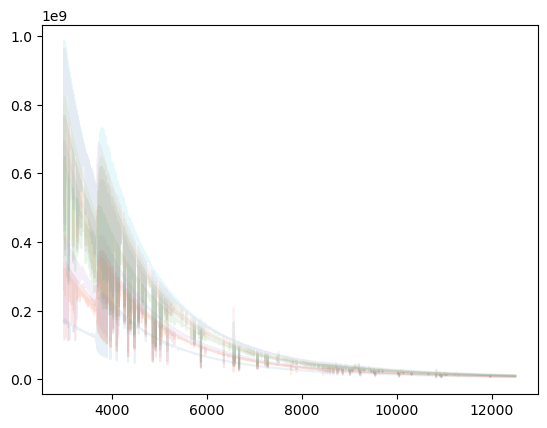

In [16]:
for i in range(1,11):
    plt.plot(df['Wavelength'][:],df['Flux{0}'.format(i)][:],alpha=0.1)